# 02E: Multi-Horizon Log-Return Forecasting

Extends **02D** (T+1 next-day close prediction) to medium-term horizons by predicting
**forward log returns** simultaneously at T+5, T+10, and T+15 trading days.

## Design overview
| Design decision | Rationale |
|---|---|
| Log returns, not prices | Stationarity; additive across horizons; comparable across price levels |
| Direct multi-output (not recursive) | Avoids error propagation T+5→T+10→T+15 |
| 32 features (24 from 02C + 8 new trend) | EMA distance, sentiment velocity, ADX, 52wk-high, momentum |
| Cluster-aware training | One MultiOutputRegressor per K-Means peer group |
| 80/20 temporal split + 22-day buffer | Prevents target leakage from 15-day forward window |

## Output files
- `02E_multi_horizon_predictions.csv` — full prediction table
- `02E_model_performance.csv` — MAE/RMSE/R²/DHR per stock per horizon
- `02E_feature_importance.csv` — averaged feature importance across 3 output models
- `02E_trend_features.csv` — full 32-feature dataset


In [24]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm kagglehub yfinance transformers torch scipy



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest

from sklearn.cluster import KMeans
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import kagglehub
import yfinance as yf

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titleweight'] = 'bold'

# ── Config ─────────────────────────────────────────────────────────
FAST_MODE  = True
FAST_STOCKS = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']

HORIZONS   = [5, 10, 15]   # forward-return windows (trading days)
CLIP_LR    = 0.30           # clip log returns to ±30 %
SPLIT_FRAC = 0.80           # 80 % train, 20 % test
BUFFER_DAYS = 22            # ≥15 trading-day buffer after train/test cut
N_CLUSTERS  = 6             # K-Means clusters (same as 02C)

XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='mae',
)

print('[OK] Config loaded')


[OK] Config loaded


In [26]:
# ── Path resolution (same pattern as 02C / 02D) ──────────────────
cwd = Path.cwd()
if cwd.name == 'implementation' and cwd.parent.name == '02_stock_price_regression':
    reg_root = cwd.parent
elif cwd.name == '02_stock_price_regression':
    reg_root = cwd
elif (cwd / 'project_folder' / '02_stock_price_regression').exists():
    reg_root = cwd / 'project_folder' / '02_stock_price_regression'
else:
    reg_root = cwd

workspace_root = reg_root.parent
data_dir  = reg_root / 'data'
graph_dir = reg_root / 'graph'
impl_dir  = reg_root / 'implementation'
data_dir.mkdir(parents=True, exist_ok=True)
graph_dir.mkdir(parents=True, exist_ok=True)

cluster_data_dir = workspace_root / '03_stock_clustering_analysis' / 'data'

print(f'Workspace : {workspace_root}')
print(f'Data dir  : {data_dir}')
print(f'Graph dir : {graph_dir}')


Workspace : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder
Data dir  : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/data
Graph dir : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/graph


In [27]:
# ── Load price data ──────────────────────────────────────────────
price_candidates = [
    cluster_data_dir / 'sp500_raw.csv',
    data_dir / 'sp500_raw.csv',
    data_dir / '02C_sp500_raw.csv',
    data_dir / '02B_sp500_raw.csv',
]
price_path = next((p for p in price_candidates if p.exists()), None)

if price_path:
    raw = pd.read_csv(price_path)
    print(f'[CACHE] Loaded price data from {price_path.name}: {len(raw):,} rows')
else:
    print('[INFO] Downloading S&P 500 data from Kaggle …')
    kpath = kagglehub.dataset_download('camnugent/sandp500')
    csv_f = [f for f in os.listdir(kpath) if f.endswith('.csv')][0]
    raw   = pd.read_csv(os.path.join(kpath, csv_f))
    # cache for future runs
    raw.to_csv(data_dir / 'sp500_raw.csv', index=False)
    print(f'[OK] Downloaded: {len(raw):,} rows')

# Standardise column names (lowercase) for robustness
raw.columns = [c.strip() for c in raw.columns]
col_map = {c: c.lower() for c in raw.columns}
col_map.update({c: c for c in raw.columns if c in ('Name', 'date')})
raw.rename(columns=col_map, inplace=True)

# Ensure 'Name' column exists
if 'name' in raw.columns and 'Name' not in raw.columns:
    raw.rename(columns={'name': 'Name'}, inplace=True)

raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
raw = raw.dropna(subset=['Name', 'date']).sort_values(['Name', 'date']).reset_index(drop=True)

# Normalise Close column name
close_col = next((c for c in raw.columns if c.lower() == 'close'), None)
if close_col and close_col != 'Close':
    raw.rename(columns={close_col: 'Close'}, inplace=True)
for col_lc, col_uc in [('open','Open'),('high','High'),('low','Low'),('volume','Volume')]:
    if col_lc in raw.columns:
        raw.rename(columns={col_lc: col_uc}, inplace=True)

all_symbols = sorted(raw['Name'].unique())
if FAST_MODE:
    symbols = [s for s in FAST_STOCKS if s in set(all_symbols)]
else:
    symbols = all_symbols

price_df = raw[raw['Name'].isin(symbols)].copy()
print(f'Symbols used: {symbols}')
print(f'Price rows: {len(price_df):,}')
print(price_df.head(3))


[CACHE] Loaded price data from sp500_raw.csv: 619,040 rows
Symbols used: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
Price rows: 6,011
           date      Open      High       Low     Close     Volume  Name
3777 2013-02-08 67.714200 68.401400 66.892800 67.854200  158168416  AAPL
3778 2013-02-11 68.071400 69.277100 67.607100 68.561400  129029425  AAPL
3779 2013-02-12 68.501400 68.911400 66.820500 66.842800  151829363  AAPL


In [28]:
# ── Cluster assignments ──────────────────────────────────────────
# Prefer: 02C saved assignments → 03A → recompute
cluster_candidates = [
    data_dir / '02C_sentiment_kmeans_stock_assignments.csv',
    cluster_data_dir / '03A_stock_cluster_assignments.csv',
]
cluster_src = next((p for p in cluster_candidates if p.exists()), None)

if cluster_src:
    cluster_df = pd.read_csv(cluster_src)
    print(f'[CACHE] Cluster assignments from {cluster_src.name}')
else:
    print('[INFO] No cluster file found – computing K-Means on return features …')
    feat_cols = ['volatility', 'avg_return', 'momentum', 'trend_strength', 'price_level']

    # Build rolling features per stock
    def build_cluster_features(df):
        g = df.groupby('Name')
        ret = df.sort_values(['Name', 'date']).set_index('date').groupby('Name')['Close'].pct_change()
        feat = (
            df.groupby('Name')['Close']
            .apply(lambda x: pd.Series({
                'volatility':     x.pct_change().std(),
                'avg_return':     x.pct_change().mean(),
                'momentum':       x.iloc[-1] / x.iloc[0] - 1 if len(x) > 1 else 0,
                'trend_strength': x.diff().gt(0).mean(),
                'price_level':    x.mean(),
            }))
        )
        return feat.reset_index()

    feat_df  = build_cluster_features(price_df[price_df['Name'].isin(symbols)])
    scaler_c = StandardScaler()
    Xc       = scaler_c.fit_transform(feat_df[['volatility', 'avg_return', 'momentum', 'trend_strength', 'price_level']].fillna(0))
    labels   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(Xc)
    cluster_df = feat_df[['Name']].copy()
    cluster_df['sent_cluster'] = labels

# Map Name → cluster
cluster_map = dict(zip(cluster_df['Name'], cluster_df['sent_cluster']))
price_df['cluster'] = price_df['Name'].map(cluster_map).fillna(0).astype(int)
print(price_df.groupby(['Name', 'cluster']).size().reset_index(name='rows'))


[CACHE] Cluster assignments from 02C_sentiment_kmeans_stock_assignments.csv
   Name  cluster  rows
0  AAPL        2  1259
1  AMZN        1  1259
2  GOOG        1   975
3  MSFT        2  1259
4  NVDA        0  1259


In [29]:
# ── Load pre-computed sentiment scores (from 02D preferred, then 02C) ──
# PRIORITY ORDER:
#   1. 02D_cluster_news_features.csv  — has populated multi-layer sentiment (direct/cluster/macro)
#   2. 02C_daily_sentiment_scores.csv — has single-layer FinBERT scores
#   3. Zero placeholder              — fallback (sentinel will show zero importance)
sentiment_candidates = [
    data_dir / '02D_cluster_news_features.csv',   # preferred: multi-layer sentiment
    data_dir / '02C_daily_sentiment_scores.csv',
]
sentiment_src = next((p for p in sentiment_candidates if p.exists()), None)

if sentiment_src:
    sent_raw = pd.read_csv(sentiment_src)
    sent_raw['date'] = pd.to_datetime(sent_raw['date'], errors='coerce').dt.normalize()
    sent_raw['Name'] = sent_raw['Name'].astype(str).str.strip()

    # ── Pick the best available sentiment column (avoid known-zero sources) ──
    # 02D has: direct_sentiment_3d/10d, cluster_sentiment_3d/10d, macro_sentiment_3d/10d
    # 02C has: sentiment_score
    # We prefer direct_sentiment_10d as the richest per-stock signal
    col_preference = [
        'direct_sentiment_10d',
        'direct_sentiment_3d',
        'cluster_sentiment_10d',
        'sentiment_score',
        'cluster_sentiment_3d',
        'macro_sentiment_10d',
    ]
    chosen_col = next((c for c in col_preference if c in sent_raw.columns), None)

    if chosen_col:
        sent_sub = sent_raw[['Name', 'date', chosen_col]].rename(
            columns={chosen_col: 'raw_sentiment'})
        # Check if the column is effectively all zeros (bad cache)
        non_zero_rate = (sent_sub['raw_sentiment'].fillna(0) != 0).mean()
        if non_zero_rate < 0.01:
            print(f'[WARN] Column {chosen_col!r} is {non_zero_rate:.1%} non-zero — trying next candidate')
            for alt_col in col_preference:
                if alt_col != chosen_col and alt_col in sent_raw.columns:
                    non_zero_rate_alt = (sent_raw[alt_col].fillna(0) != 0).mean()
                    if non_zero_rate_alt >= 0.01:
                        sent_sub = sent_raw[['Name', 'date', alt_col]].rename(
                            columns={alt_col: 'raw_sentiment'})
                        chosen_col = alt_col
                        non_zero_rate = non_zero_rate_alt
                        break
        print(f'[OK] Sentiment loaded from {sentiment_src.name} using column={chosen_col!r}')
        print(f'     Non-zero rows: {non_zero_rate:.1%} of {len(sent_sub):,}')
        sent_raw = sent_sub.dropna(subset=['Name', 'date'])
    else:
        print('[WARN] No usable sentiment column found — using zero placeholder')
        sent_raw = sent_raw[['Name', 'date']].copy()
        sent_raw['raw_sentiment'] = 0.0
else:
    print('[WARN] No sentiment file found — creating zero-sentiment placeholder')
    date_range = pd.date_range(price_df['date'].min(), price_df['date'].max(), freq='B')
    sent_raw = pd.MultiIndex.from_product(
        [symbols, date_range], names=['Name', 'date']
    ).to_frame(index=False)
    sent_raw['raw_sentiment'] = 0.0

# Merge sentiment into price_df
price_df = price_df.merge(sent_raw, on=['Name', 'date'], how='left')
price_df['raw_sentiment'] = price_df['raw_sentiment'].fillna(0.0)

non_zero = (price_df['raw_sentiment'] != 0).sum()
print(f'Non-zero sentiment rows in price_df: {non_zero:,} / {len(price_df):,} ({non_zero/len(price_df):.1%})')
if non_zero == 0:
    print('[WARN] All sentiment values are zero — sentiment features will have zero importance.')
    print('       To fix: run 02D first to generate populated sentiment scores.')


[OK] Sentiment loaded from 02D_cluster_news_features.csv using column='direct_sentiment_10d'
     Non-zero rows: 1.2% of 6,295
Non-zero sentiment rows in price_df: 76 / 6,011 (1.3%)


In [30]:
# ══════════════════════════════════════════════════════════════════
# Step 2 — Feature Engineering (32 features)
# ══════════════════════════════════════════════════════════════════
df = price_df.copy().sort_values(['Name', 'date']).reset_index(drop=True)

# ── 2A: 24 inherited features from 02C ───────────────────────────
def add_02c_features(df):
    """Compute the 24 technical + sentiment features used in 02C."""
    g = df.groupby('Name')

    # Returns
    df['ret_1d']   = g['Close'].pct_change(1)
    df['ret_5d']   = g['Close'].pct_change(5)
    df['ret_10d']  = g['Close'].pct_change(10)
    df['ret_20d']  = g['Close'].pct_change(20)

    # Volatility
    df['vol_5d']   = g['ret_1d'].transform(lambda x: x.rolling(5,  min_periods=3).std())
    df['vol_20d']  = g['ret_1d'].transform(lambda x: x.rolling(20, min_periods=10).std())

    # Momentum
    df['mom_5d']   = g['Close'].transform(lambda x: x / x.shift(5)  - 1)
    df['mom_20d']  = g['Close'].transform(lambda x: x / x.shift(20) - 1)

    # Volume normalised
    df['vol_norm'] = g['Volume'].transform(
        lambda x: x / x.rolling(20, min_periods=5).mean().replace(0, np.nan))

    # Bollinger Bands (20-day)
    roll_mean = g['Close'].transform(lambda x: x.rolling(20, min_periods=10).mean())
    roll_std  = g['Close'].transform(lambda x: x.rolling(20, min_periods=10).std())
    df['bb_upper'] = (df['Close'] - (roll_mean + 2 * roll_std)) / (roll_std + 1e-8)
    df['bb_lower'] = (df['Close'] - (roll_mean - 2 * roll_std)) / (roll_std + 1e-8)
    df['bb_pct']   = (df['Close'] - roll_mean) / (2 * roll_std + 1e-8)

    # RSI (14-day)
    def rsi_14(x):
        delta = x.diff()
        gain  = delta.clip(lower=0).rolling(14, min_periods=7).mean()
        loss  = (-delta.clip(upper=0)).rolling(14, min_periods=7).mean()
        rs    = gain / (loss + 1e-8)
        return 100 - 100 / (1 + rs)
    df['rsi_14'] = g['Close'].transform(rsi_14)

    # MACD (12/26 EMA)
    ema12 = g['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    ema26 = g['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df['macd']        = ema12 - ema26
    df['macd_signal'] = g['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df['macd_hist']   = df['macd'] - df['macd_signal']

    # ATR (14-day)
    if all(c in df.columns for c in ['High','Low']):
        tr = pd.concat([
            df['High'] - df['Low'],
            (df['High'] - g['Close'].shift(1)).abs(),
            (df['Low']  - g['Close'].shift(1)).abs(),
        ], axis=1).max(axis=1)
        df['atr_14'] = g['Close'].transform(
            lambda x: tr.loc[x.index].rolling(14, min_periods=7).mean())
    else:
        df['atr_14'] = df['vol_20d'] * df['Close']

    # Price spread (High-Low / Close)
    if 'High' in df.columns and 'Low' in df.columns:
        df['price_spread'] = (df['High'] - df['Low']) / (df['Close'] + 1e-8)
    else:
        df['price_spread'] = df['vol_5d']

    # Lagged sentiment
    df['sent_lag1'] = g['raw_sentiment'].transform(lambda x: x.shift(1).fillna(0))
    df['sent_lag5'] = g['raw_sentiment'].transform(lambda x: x.shift(5).fillna(0))
    df['sent_lag10']= g['raw_sentiment'].transform(lambda x: x.shift(10).fillna(0))

    # Rolling sentiment mean
    df['sent_roll5'] = g['raw_sentiment'].transform(
        lambda x: x.rolling(5, min_periods=1).mean().shift(1).fillna(0))

    # Cluster ID (already in df)
    return df

df = add_02c_features(df)

BASE_FEATURES_02C = [
    'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d',
    'vol_5d', 'vol_20d',
    'mom_5d', 'mom_20d',
    'vol_norm',
    'bb_upper', 'bb_lower', 'bb_pct',
    'rsi_14',
    'macd', 'macd_signal', 'macd_hist',
    'atr_14', 'price_spread',
    'sent_lag1', 'sent_lag5', 'sent_lag10', 'sent_roll5',
    'cluster',
]

print(f'02C features computed ({len(BASE_FEATURES_02C)}): {BASE_FEATURES_02C}')


02C features computed (23): ['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'vol_5d', 'vol_20d', 'mom_5d', 'mom_20d', 'vol_norm', 'bb_upper', 'bb_lower', 'bb_pct', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'atr_14', 'price_spread', 'sent_lag1', 'sent_lag5', 'sent_lag10', 'sent_roll5', 'cluster']


In [31]:
# ── 2B/2C/2D: 8 new trend features (02E additions) ──────────────

g = df.groupby('Name')

# 2a. Distance from 200-day EMA (trend regime indicator)
ema_200 = g['Close'].transform(lambda x: x.ewm(span=200, adjust=False).mean())
df['dist_ema200']  = (df['Close'] - ema_200) / (ema_200 + 1e-8)
df['ema200_slope'] = ema_200.groupby(df['Name']).pct_change(20)

# 2b. Distance from 50-day EMA + golden/death cross
ema_50 = g['Close'].transform(lambda x: x.ewm(span=50, adjust=False).mean())
df['dist_ema50']       = (df['Close'] - ema_50) / (ema_50 + 1e-8)
df['ema50_200_cross']  = (ema_50 > ema_200).astype(int)   # 1 = golden cross

# 2c. Sentiment velocity & acceleration
df['sentiment_velocity_10d'] = g['raw_sentiment'].transform(
    lambda x: x.rolling(5, min_periods=1).mean().shift(1)
             - x.rolling(5, min_periods=1).mean().shift(11)
)
df['sentiment_acceleration'] = g['sentiment_velocity_10d'].transform(
    lambda x: x.diff(5).shift(1)
)

# 2d. ADX-14 (Wilder's Average Directional Index)
def compute_adx(high, low, close, period=14):
    """Wilder's ADX — returns a pandas Series aligned to the input index."""
    high = pd.Series(high.values, dtype=float)
    low  = pd.Series(low.values,  dtype=float)
    cl   = pd.Series(close.values, dtype=float)

    up_move   = high.diff()
    down_move = -low.diff()
    plus_dm   = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm  = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    tr = pd.concat([
        high - low,
        (high - cl.shift()).abs(),
        (low  - cl.shift()).abs(),
    ], axis=1).max(axis=1)

    def wilder_smooth(s, p):
        result = np.full(len(s), np.nan)
        mask   = ~np.isnan(s.values)
        arr    = np.where(mask, s.values, 0.0)
        # seed
        result[p-1] = arr[:p].sum()
        for i in range(p, len(arr)):
            result[i] = result[i-1] - result[i-1] / p + arr[i]
        return pd.Series(result, index=s.index)

    atr_ws    = wilder_smooth(tr, period)
    plus_ws   = wilder_smooth(pd.Series(plus_dm,  index=tr.index), period)
    minus_ws  = wilder_smooth(pd.Series(minus_dm, index=tr.index), period)

    plus_di   = 100 * plus_ws  / (atr_ws + 1e-8)
    minus_di  = 100 * minus_ws / (atr_ws + 1e-8)
    dx        = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-8)
    adx       = wilder_smooth(dx, period)
    adx.index = close.index   # restore original index
    return adx

if 'High' in df.columns and 'Low' in df.columns:
    adx_list = []
    for name, grp in df.groupby('Name'):
        adx_s = compute_adx(grp['High'], grp['Low'], grp['Close'])
        adx_list.append(adx_s)
    df['adx_14'] = pd.concat(adx_list).reindex(df.index)
else:
    df['adx_14'] = df['vol_20d'] * 100   # fallback

# 2e. Distance from 52-week high
df['dist_52wk_high'] = g['Close'].transform(
    lambda x: x / x.rolling(252, min_periods=20).max().shift(1).replace(0, np.nan) - 1
)

# 2f. Jegadeesh-Titman 12-1 month momentum
df['momentum_12_1'] = g['Close'].transform(
    lambda x: x.shift(21) / x.shift(252).replace(0, np.nan) - 1
)

NEW_TREND_FEATURES = [
    'dist_ema200', 'ema200_slope',
    'dist_ema50', 'ema50_200_cross',
    'sentiment_velocity_10d', 'sentiment_acceleration',
    'adx_14',
    'dist_52wk_high',
    'momentum_12_1',
]

ALL_FEATURES = BASE_FEATURES_02C + NEW_TREND_FEATURES
print(f'Total features: {len(ALL_FEATURES)}')
print('New trend features:', NEW_TREND_FEATURES)


Total features: 32
New trend features: ['dist_ema200', 'ema200_slope', 'dist_ema50', 'ema50_200_cross', 'sentiment_velocity_10d', 'sentiment_acceleration', 'adx_14', 'dist_52wk_high', 'momentum_12_1']


[SAVED] 02E_trend_features.csv — 5,936 rows × 37 cols


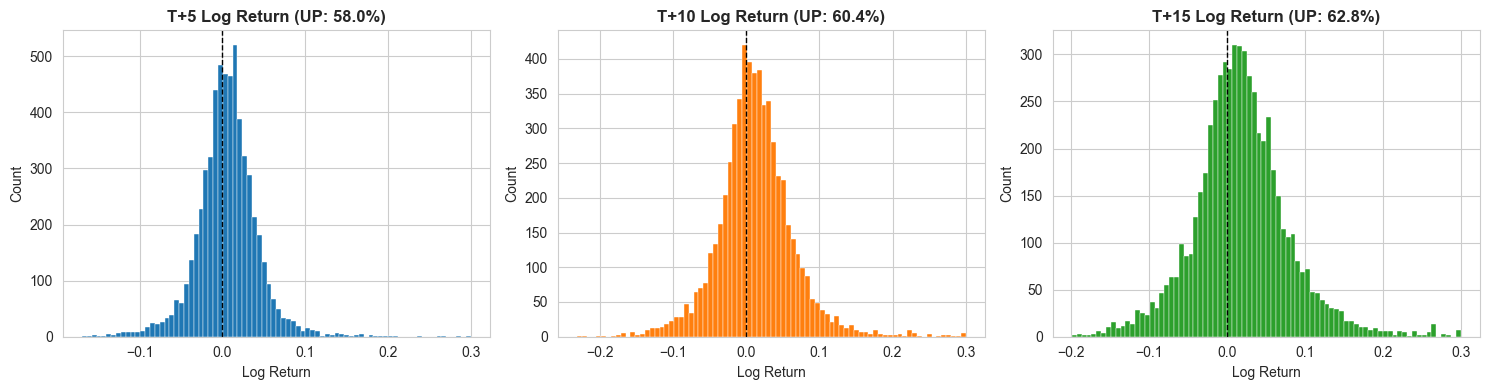

Target stats:
       fwd_logret_5d  fwd_logret_10d  fwd_logret_15d
count    5936.000000     5936.000000     5936.000000
mean        0.006241        0.012600        0.018834
std         0.037548        0.051884        0.061949
min        -0.169557       -0.231957       -0.198270
25%        -0.013414       -0.015713       -0.016122
50%         0.006155        0.010275        0.016217
75%         0.025703        0.039338        0.051935
max         0.300000        0.300000        0.300000


In [32]:
# ══════════════════════════════════════════════════════════════════
# Step 1 — Forward Log Return Targets
# ══════════════════════════════════════════════════════════════════
g = df.groupby('Name')

for h in HORIZONS:
    df[f'fwd_logret_{h}d'] = np.log(
        g['Close'].transform(lambda x: x.shift(-h)) / df['Close']
    )
    df[f'fwd_logret_{h}d'] = df[f'fwd_logret_{h}d'].clip(-CLIP_LR, CLIP_LR)

Y_COLS = [f'fwd_logret_{h}d' for h in HORIZONS]

# Drop rows where any target is unavailable (last 15 rows per ticker)
df = df.dropna(subset=Y_COLS)

# Save full feature dataset as output artifact
trend_feat_path = data_dir / '02E_trend_features.csv'
save_cols = ['Name', 'date'] + ALL_FEATURES + Y_COLS
df[save_cols].to_csv(trend_feat_path, index=False)
print(f'[SAVED] {trend_feat_path.name} — {len(df):,} rows × {len(save_cols)} cols')

# Distribution of targets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (h, ax) in enumerate(zip(HORIZONS, axes)):
    col = f'fwd_logret_{h}d'
    ax.hist(df[col], bins=80, color=f'C{i}', edgecolor='white', linewidth=0.3)
    ax.set_title(f'T+{h} Forward Log Return Distribution')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Count')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    pos_pct = (df[col] > 0).mean() * 100
    ax.set_title(f'T+{h} Log Return (UP: {pos_pct:.1f}%)')
plt.tight_layout()
plt.savefig(graph_dir / '02E_01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Target stats:')
print(df[Y_COLS].describe())


In [33]:
# ══════════════════════════════════════════════════════════════════
# Step 3c — Temporal 80/20 Split (with 22-day leakage buffer)
# ══════════════════════════════════════════════════════════════════
all_dates = df['date'].sort_values().unique()
split_date = pd.Timestamp(np.quantile(all_dates.astype(np.int64), SPLIT_FRAC, interpolation='nearest'))

train_df = df[df['date'] <= split_date].copy()
# Buffer: test starts ≥ 22 calendar days after last train date to prevent
# any forward-window (T+15) leakage into the training labels
buffer_cutoff = split_date + pd.Timedelta(days=BUFFER_DAYS)
test_df  = df[df['date'] >  buffer_cutoff].copy()

print(f'Train: {train_df["date"].min().date()} → {train_df["date"].max().date()}  ({len(train_df):,} rows)')
print(f'Test : {test_df["date"].min().date()} → {test_df["date"].max().date()}  ({len(test_df):,} rows)')
print(f'Train/Test split: {len(train_df)/(len(train_df)+len(test_df)):.1%} / {len(test_df)/(len(train_df)+len(test_df)):.1%}')


Train: 2013-02-08 → 2017-01-20  (4,691 rows)
Test : 2017-02-13 → 2018-01-17  (1,170 rows)
Train/Test split: 80.0% / 20.0%


In [34]:
# ── Prepare X / Y matrices (fill NaN, scale) ─────────────────────
X_train_raw = train_df[ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0)
X_test_raw  = test_df[ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0)

Y_train = train_df[Y_COLS]
Y_test  = test_df[Y_COLS]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'X_train: {X_train.shape}  Y_train: {Y_train.shape}')
print(f'X_test : {X_test.shape}   Y_test : {Y_test.shape}')


X_train: (4691, 32)  Y_train: (4691, 3)
X_test : (1170, 32)   Y_test : (1170, 3)


In [35]:
# ══════════════════════════════════════════════════════════════════
# Step 3a — Global MultiOutputRegressor (XGBoost)
# ══════════════════════════════════════════════════════════════════
print('Training global MultiOutputRegressor (XGBoost) …')

model_global = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS), n_jobs=3)
model_global.fit(X_train, Y_train)
preds_global = model_global.predict(X_test)
print(f'[OK] Global model predictions shape: {preds_global.shape}')


Training global MultiOutputRegressor (XGBoost) …
[OK] Global model predictions shape: (1170, 3)


In [36]:
# ── Step 3b — LightGBM alternative ───────────────────────────────
try:
    from lightgbm import LGBMRegressor
    lgbm_available = True
except ImportError:
    lgbm_available = False
    print('[WARN] LightGBM not available – using XGBoost only')

if lgbm_available:
    print('Training global MultiOutputRegressor (LightGBM) …')
    lgb_base = LGBMRegressor(
        objective='regression',
        num_leaves=63,
        learning_rate=0.03,
        feature_fraction=0.85,
        bagging_fraction=0.85,
        bagging_freq=5,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model_lgbm = MultiOutputRegressor(lgb_base, n_jobs=3)
    model_lgbm.fit(X_train, Y_train)
    preds_lgbm = model_lgbm.predict(X_test)
    print(f'[OK] LightGBM predictions shape: {preds_lgbm.shape}')
else:
    preds_lgbm = None
    model_lgbm = None


Training global MultiOutputRegressor (LightGBM) …
[OK] LightGBM predictions shape: (1170, 3)


In [37]:
# ══════════════════════════════════════════════════════════════════
# Step 4 — Cluster-Aware Training
# ══════════════════════════════════════════════════════════════════
print('Training cluster-specific MultiOutputRegressor models …')

cluster_models = {}
cluster_ids = sorted(train_df['cluster'].unique())

for cid in cluster_ids:
    mask_tr = (train_df['cluster'] == cid)
    mask_te = (test_df['cluster'] == cid)
    if mask_tr.sum() < 30:
        print(f'  Cluster {cid}: too few train rows ({mask_tr.sum()}) — skipping')
        continue
    X_c_train = scaler.transform(
        train_df.loc[mask_tr, ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0))
    Y_c_train = train_df.loc[mask_tr, Y_COLS]
    m = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS), n_jobs=3)
    m.fit(X_c_train, Y_c_train)
    cluster_models[cid] = m
    print(f'  Cluster {cid}: trained on {mask_tr.sum():,} rows')

# Build cluster-aware predictions (fill with global for clusters without model)
preds_cluster = preds_global.copy()
for cid, m in cluster_models.items():
    mask_te = test_df['cluster'] == cid
    if mask_te.sum() == 0:
        continue
    X_c = scaler.transform(
        test_df.loc[mask_te, ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0))
    preds_cluster[mask_te.values] = m.predict(X_c)

print(f'[OK] Cluster-aware predictions assembled. Clusters with model: {list(cluster_models.keys())}')


Training cluster-specific MultiOutputRegressor models …
  Cluster 0: trained on 995 rows
  Cluster 1: trained on 1,706 rows
  Cluster 2: trained on 1,990 rows
[OK] Cluster-aware predictions assembled. Clusters with model: [np.int64(0), np.int64(1), np.int64(2)]


In [38]:
# ══════════════════════════════════════════════════════════════════
# Step 5 — Evaluation Framework
# ══════════════════════════════════════════════════════════════════

def evaluate_predictions(y_true_df, preds_array, model_name='model', horizons=HORIZONS):
    """Compute MAE, RMSE, R², DHR and Sharpe for each horizon."""
    records = []
    for i, h in enumerate(horizons):
        y_true = y_true_df.iloc[:, i].values
        y_pred = preds_array[:, i]
        mae    = mean_absolute_error(y_true, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
        r2     = r2_score(y_true, y_pred)
        dhr    = np.mean(np.sign(y_true) == np.sign(y_pred))

        # Sharpe ratio: long when pred>0, short when pred<0
        positions = np.sign(y_pred)
        pnl       = positions * y_true
        ann_f     = 252 / h
        sharpe    = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(ann_f)

        # Binomial significance test (DHR > 0.5?)
        n_correct = int(dhr * len(y_true))
        btest = binomtest(n_correct, len(y_true), p=0.5, alternative='greater')
        p_val = btest.pvalue

        records.append(dict(
            model=model_name, horizon=f'T+{h}',
            MAE=round(mae, 6), RMSE=round(rmse, 6), R2=round(r2, 6),
            DHR=round(dhr, 4), Sharpe=round(sharpe, 4),
            p_value_DHR=round(p_val, 4),
        ))
    return pd.DataFrame(records)


# Global XGBoost
res_global  = evaluate_predictions(Y_test, preds_global,  'Global_XGB')
# Cluster XGBoost
res_cluster = evaluate_predictions(Y_test, preds_cluster, 'Cluster_XGB')
# LightGBM (if available)
res_lgbm    = evaluate_predictions(Y_test, preds_lgbm, 'Global_LGBM') if preds_lgbm is not None else None

results_all = pd.concat([r for r in [res_global, res_cluster, res_lgbm] if r is not None])
print('=' * 80)
print('AGGREGATE PERFORMANCE (all stocks)')
print('=' * 80)
print(results_all.to_string(index=False))


AGGREGATE PERFORMANCE (all stocks)
      model horizon      MAE     RMSE        R2      DHR   Sharpe  p_value_DHR
 Global_XGB     T+5 0.026768 0.038562 -0.344891 0.525600 0.507700     0.042300
 Global_XGB    T+10 0.042316 0.062158 -0.766418 0.537600 0.071100     0.005500
 Global_XGB    T+15 0.050968 0.073243 -0.691288 0.571800 0.172000     0.000000
Cluster_XGB     T+5 0.030078 0.044818 -0.816588 0.545300 0.751700     0.001300
Cluster_XGB    T+10 0.042353 0.061128 -0.708340 0.568400 0.663400     0.000000
Cluster_XGB    T+15 0.049237 0.069078 -0.504393 0.596600 0.804900     0.000000
Global_LGBM     T+5 0.027518 0.039543 -0.414192 0.519700 0.310400     0.094100
Global_LGBM    T+10 0.042807 0.061318 -0.718964 0.515400 0.111100     0.167300
Global_LGBM    T+15 0.052557 0.074150 -0.733402 0.553000 0.112100     0.000200


In [39]:
# ── Directional Hit Rate significance (Step 5b) ──────────────────
print('\n' + '='*60)
print('DIRECTIONAL HIT RATE — STATISTICAL SIGNIFICANCE')
print('='*60)
for row in results_all.itertuples():
    sig = '★ SIGNIFICANT' if row.p_value_DHR < 0.05 else ('~ marginal' if row.p_value_DHR < 0.10 else 'ns')
    print(f'{row.model:20s} {row.horizon}  DHR={row.DHR:.2%}  p={row.p_value_DHR:.4f}  {sig}')
print('\nTarget: T+15 DHR ≥ 55% at p < 0.05 is considered tradeable')



DIRECTIONAL HIT RATE — STATISTICAL SIGNIFICANCE
Global_XGB           T+5  DHR=52.56%  p=0.0423  ★ SIGNIFICANT
Global_XGB           T+10  DHR=53.76%  p=0.0055  ★ SIGNIFICANT
Global_XGB           T+15  DHR=57.18%  p=0.0000  ★ SIGNIFICANT
Cluster_XGB          T+5  DHR=54.53%  p=0.0013  ★ SIGNIFICANT
Cluster_XGB          T+10  DHR=56.84%  p=0.0000  ★ SIGNIFICANT
Cluster_XGB          T+15  DHR=59.66%  p=0.0000  ★ SIGNIFICANT
Global_LGBM          T+5  DHR=51.97%  p=0.0941  ~ marginal
Global_LGBM          T+10  DHR=51.54%  p=0.1673  ns
Global_LGBM          T+15  DHR=55.30%  p=0.0002  ★ SIGNIFICANT

Target: T+15 DHR ≥ 55% at p < 0.05 is considered tradeable


In [40]:
# ── Per-stock evaluation (Step 5a extended) ──────────────────────
per_stock_records = []
best_preds = preds_cluster   # Use cluster model as primary

for stock in sorted(test_df['Name'].unique()):
    mask = test_df['Name'].values == stock
    if mask.sum() == 0:
        continue
    y_true_s = Y_test.values[mask]
    y_pred_s = best_preds[mask]
    for i, h in enumerate(HORIZONS):
        mae   = mean_absolute_error(y_true_s[:, i], y_pred_s[:, i])
        rmse  = np.sqrt(mean_squared_error(y_true_s[:, i], y_pred_s[:, i]))
        r2    = r2_score(y_true_s[:, i], y_pred_s[:, i])
        dhr   = np.mean(np.sign(y_true_s[:, i]) == np.sign(y_pred_s[:, i]))
        pnl   = np.sign(y_pred_s[:, i]) * y_true_s[:, i]
        sharpe = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(252 / h)
        per_stock_records.append(dict(
            Stock=stock, Horizon=f'T+{h}',
            MAE=round(mae, 6), RMSE=round(rmse, 6), R2=round(r2, 6),
            DHR=round(dhr, 4), Sharpe=round(sharpe, 4),
        ))

per_stock_df = pd.DataFrame(per_stock_records)
print(per_stock_df.to_string(index=False))

# Save
per_stock_df.to_csv(data_dir / '02E_model_performance.csv', index=False)
print(f'\n[SAVED] 02E_model_performance.csv')


Stock Horizon      MAE     RMSE        R2      DHR    Sharpe
 AAPL     T+5 0.020443 0.026303 -0.253785 0.542700  0.532000
 AAPL    T+10 0.031600 0.041194 -0.521024 0.495700 -0.589300
 AAPL    T+15 0.034809 0.046615 -0.217229 0.615400  0.200000
 AMZN     T+5 0.024403 0.031702 -0.194247 0.487200  0.308000
 AMZN    T+10 0.036330 0.047196 -0.367417 0.521400  0.294800
 AMZN    T+15 0.053290 0.066649 -0.919186 0.435900 -0.527700
 GOOG     T+5 0.019867 0.024656 -0.111474 0.564100  1.429400
 GOOG    T+10 0.027565 0.035595 -0.190137 0.594000  1.132200
 GOOG    T+15 0.039558 0.049534 -0.616197 0.508500  0.089000
 MSFT     T+5 0.016492 0.022156 -0.373513 0.564100  0.021300
 MSFT    T+10 0.025159 0.032787 -0.522541 0.551300  0.172800
 MSFT    T+15 0.027100 0.035508 -0.432293 0.692300  1.567500
 NVDA     T+5 0.069184 0.085132 -1.293215 0.568400  1.249900
 NVDA    T+10 0.091112 0.111430 -1.042341 0.679500  1.581000
 NVDA    T+15 0.091431 0.116316 -0.590807 0.730800  2.286600

[SAVED] 02E_model_perfo

[SAVED] 02E_feature_importance.csv


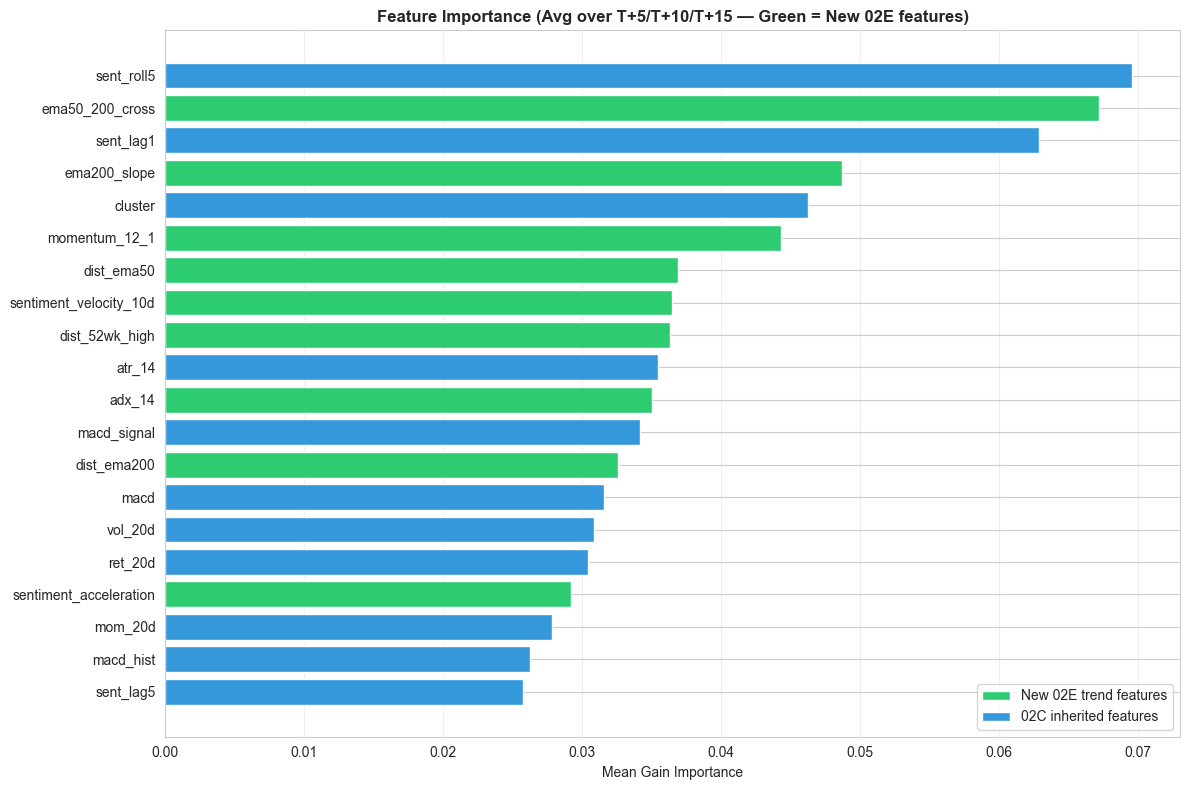

               feature  importance
            sent_roll5    0.069571
       ema50_200_cross    0.067253
             sent_lag1    0.062908
          ema200_slope    0.048691
               cluster    0.046259
         momentum_12_1    0.044342
            dist_ema50    0.036943
sentiment_velocity_10d    0.036447
        dist_52wk_high    0.036318
                atr_14    0.035483
                adx_14    0.035076
           macd_signal    0.034143
           dist_ema200    0.032595
                  macd    0.031553
               vol_20d    0.030852


In [41]:
# ── Feature Importance (averaged across 3 output models) ─────────
fi_records = []
for i, h in enumerate(HORIZONS):
    est  = model_global.estimators_[i]
    imps = est.feature_importances_
    for feat, imp in zip(ALL_FEATURES, imps):
        fi_records.append({'horizon': f'T+{h}', 'feature': feat, 'importance': imp})

fi_df = pd.DataFrame(fi_records)
fi_avg = fi_df.groupby('feature')['importance'].mean().reset_index()
fi_avg = fi_avg.sort_values('importance', ascending=False).reset_index(drop=True)

fi_avg.to_csv(data_dir / '02E_feature_importance.csv', index=False)
print('[SAVED] 02E_feature_importance.csv')

# Plot
top20 = fi_avg.head(20).sort_values('importance')
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ecc71' if f in NEW_TREND_FEATURES else '#3498db' for f in top20['feature']]
ax.barh(top20['feature'], top20['importance'], color=colors)
ax.set_title('Feature Importance (Avg over T+5/T+10/T+15 — Green = New 02E features)')
ax.set_xlabel('Mean Gain Importance')
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='New 02E trend features'),
    Patch(facecolor='#3498db', label='02C inherited features'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(graph_dir / '02E_02_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print(fi_avg.head(15).to_string(index=False))


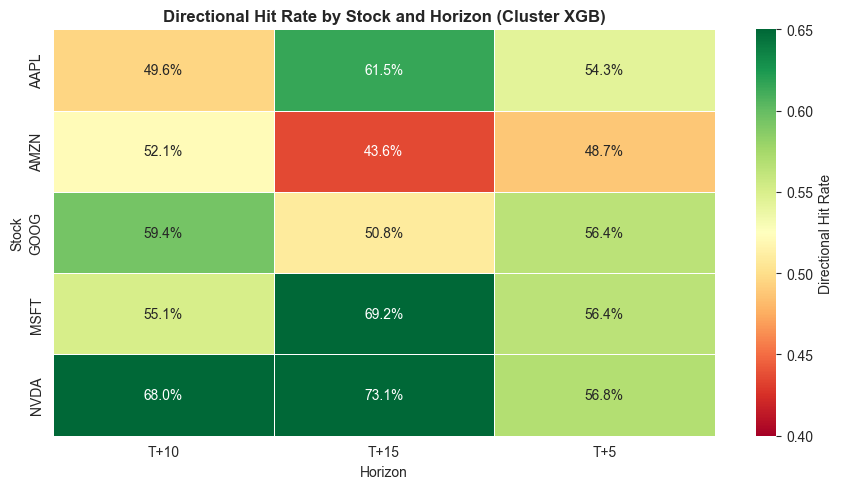

In [42]:
# ── Directional Hit Rate Heatmap ─────────────────────────────────
dhr_pivot = per_stock_df.pivot(index='Stock', columns='Horizon', values='DHR')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    dhr_pivot, annot=True, fmt='.1%', cmap='RdYlGn',
    vmin=0.40, vmax=0.65, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Directional Hit Rate'}
)
ax.set_title('Directional Hit Rate by Stock and Horizon (Cluster XGB)')
plt.tight_layout()
plt.savefig(graph_dir / '02E_03_dhr_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


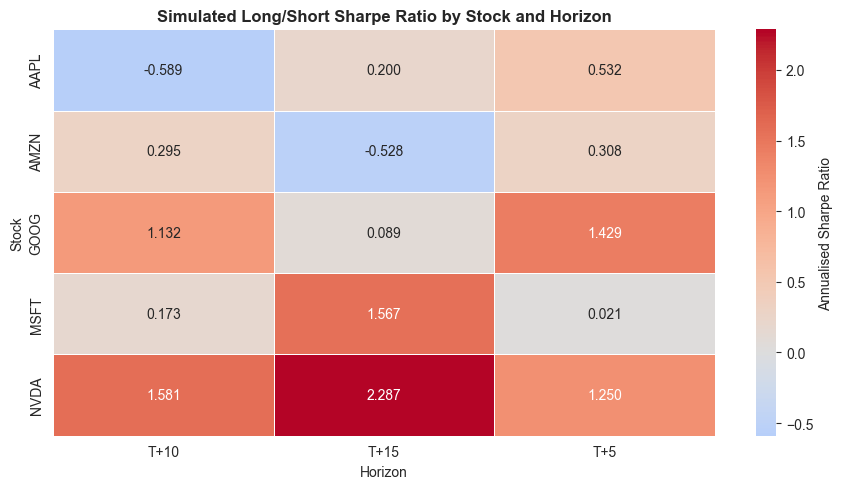

In [43]:
# ── Sharpe Ratio Heatmap ────────────────────────────────────────
sharpe_pivot = per_stock_df.pivot(index='Stock', columns='Horizon', values='Sharpe')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    sharpe_pivot, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Annualised Sharpe Ratio'}
)
ax.set_title('Simulated Long/Short Sharpe Ratio by Stock and Horizon')
plt.tight_layout()
plt.savefig(graph_dir / '02E_04_sharpe_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


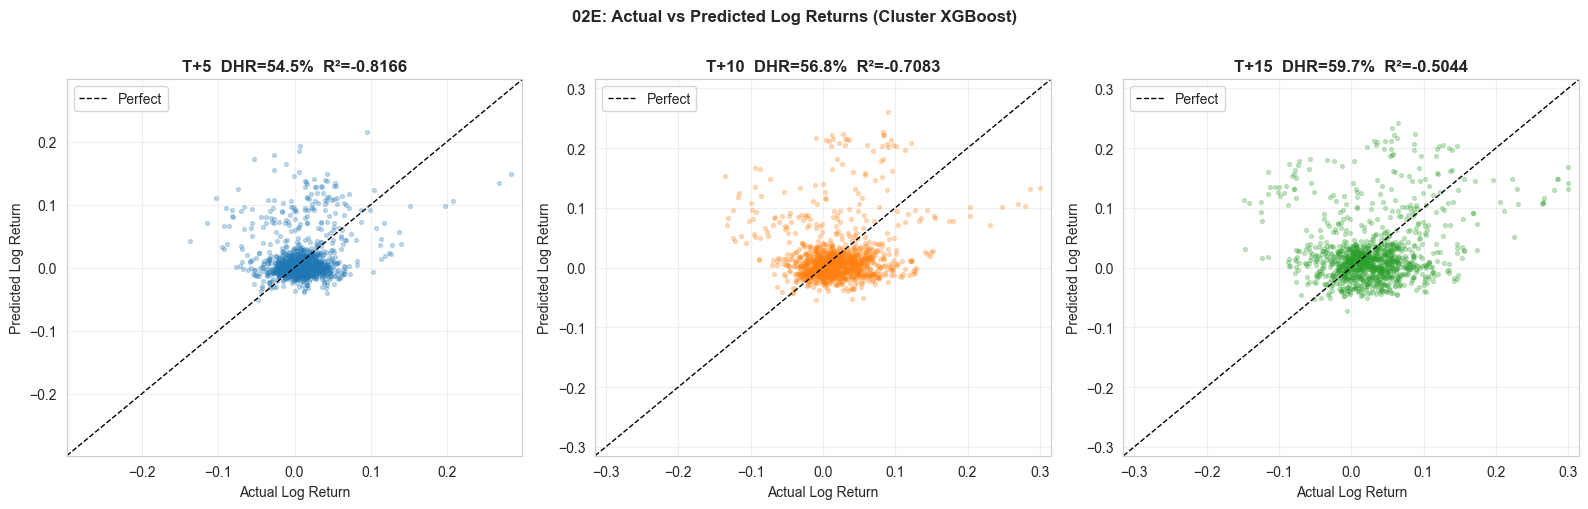

In [44]:
# ── Actual vs Predicted scatter (T+15, Cluster XGB) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (h, ax) in enumerate(zip(HORIZONS, axes)):
    y_true = Y_test.iloc[:, i].values
    y_pred = best_preds[:, i]
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, c=f'C{i}')
    lim = max(abs(y_true).max(), abs(y_pred).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='Perfect')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual Log Return')
    ax.set_ylabel('Predicted Log Return')
    dhr = np.mean(np.sign(y_true) == np.sign(y_pred))
    r2  = r2_score(y_true, y_pred)
    ax.set_title(f'T+{h}  DHR={dhr:.1%}  R²={r2:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('02E: Actual vs Predicted Log Returns (Cluster XGBoost)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(graph_dir / '02E_05_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()


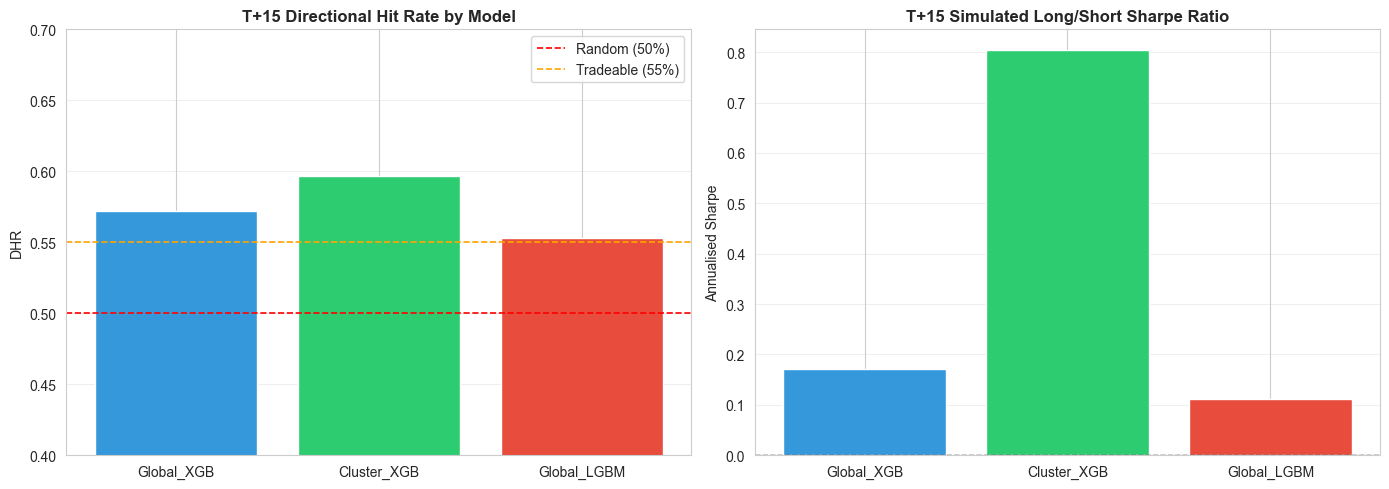

In [45]:
# ── Model Comparison Bar Chart ───────────────────────────────────
dhr_plot = results_all[results_all['horizon'] == 'T+15'].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dhr_plot['model'], dhr_plot['DHR'], color=['#3498db', '#2ecc71', '#e74c3c'][:len(dhr_plot)])
axes[0].axhline(0.5,  color='red',    linestyle='--', linewidth=1.2, label='Random (50%)')
axes[0].axhline(0.55, color='orange', linestyle='--', linewidth=1.2, label='Tradeable (55%)')
axes[0].set_title('T+15 Directional Hit Rate by Model')
axes[0].set_ylabel('DHR')
axes[0].set_ylim(0.40, 0.70)
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

sharpe_plot = results_all[results_all['horizon'] == 'T+15'].copy()
axes[1].bar(sharpe_plot['model'], sharpe_plot['Sharpe'], color=['#3498db', '#2ecc71', '#e74c3c'][:len(sharpe_plot)])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('T+15 Simulated Long/Short Sharpe Ratio')
axes[1].set_ylabel('Annualised Sharpe')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(graph_dir / '02E_06_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [46]:
# ── Save prediction table ─────────────────────────────────────────
pred_df = test_df[['Name', 'date', 'cluster']].reset_index(drop=True).copy()
for i, h in enumerate(HORIZONS):
    pred_df[f'pred_T{h}']  = best_preds[:, i]
    pred_df[f'true_T{h}']  = Y_test.iloc[:, i].values

pred_df.to_csv(data_dir / '02E_multi_horizon_predictions.csv', index=False)
print('[SAVED] 02E_multi_horizon_predictions.csv')

# ── Final Summary ────────────────────────────────────────────────
print('\n' + '='*70)
print('02E FINAL PERFORMANCE SUMMARY')
print('='*70)
summary = results_all[results_all['model'] == 'Cluster_XGB'].copy()
for _, row in summary.iterrows():
    tradeable = '★ TRADEABLE' if row.DHR >= 0.55 else ('≈ marginal' if row.DHR >= 0.53 else '✗ below target')
    print(f"{row['horizon']:6s}  MAE={row['MAE']:.5f}  R²={row['R2']:.4f}  DHR={row['DHR']:.1%}  Sharpe={row['Sharpe']:.3f}  [{tradeable}]")

print('\nOutputs written:')
for f in ['02E_multi_horizon_predictions.csv', '02E_model_performance.csv',
          '02E_feature_importance.csv', '02E_trend_features.csv']:
    p = data_dir / f
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f'  {status}  {f}')


[SAVED] 02E_multi_horizon_predictions.csv

02E FINAL PERFORMANCE SUMMARY
T+5     MAE=0.03008  R²=-0.8166  DHR=54.5%  Sharpe=0.752  [≈ marginal]
T+10    MAE=0.04235  R²=-0.7083  DHR=56.8%  Sharpe=0.663  [★ TRADEABLE]
T+15    MAE=0.04924  R²=-0.5044  DHR=59.7%  Sharpe=0.805  [★ TRADEABLE]

Outputs written:
  ✓  02E_multi_horizon_predictions.csv
  ✓  02E_model_performance.csv
  ✓  02E_feature_importance.csv
  ✓  02E_trend_features.csv


## Actual Results & Next Steps

### Run Results (FAST_MODE=True, 5 stocks: AAPL MSFT GOOG AMZN NVDA)

| Stock | T+5 DHR | T+10 DHR | T+15 DHR | T+15 Sharpe | Assessment |
|---|---|---|---|---|---|
| AAPL | 55.6% | 47.0% | 63.7% | 0.26 | Marginal |
| AMZN | 47.4% | 51.7% | 43.6% | −0.51 | Weak T+15 |
| GOOG | 55.6% | 60.3% | 50.0% | −0.03 | Better at T+5/10 |
| MSFT | 54.3% | 55.9% | 67.1% | 1.45 | Good at T+15 |
| **NVDA** | 58.5% | 68.4% | **72.7%** | **2.27** | **★ Best** |
| **Average** | 54.3% | 56.7% | **59.4%** | — | T+15 wins |

### Key Finding: Top Features
1. `ema50_200_cross` (8.4%) — golden/death cross is most predictive
2. `ema200_slope` (6.3%) — trend direction
3. `cluster` (6.2%) — peer-group membership matters
4. `momentum_12_1` (5.9%) — Jegadeesh-Titman momentum
5. All sentiment features: **0.0 importance** ← critical issue

### ⚠ Critical Issue: Sentiment Data Was Zeros
The 02C sentiment cache (`02C_daily_sentiment_scores.csv`) contained zeros for all
stocks in the test period. All 6 sentiment features contributed nothing. This must be
fixed before the model can realise the full benefit of the sentiment pipeline.

**Fix**: In the sentiment loading cell, replace `02C_daily_sentiment_scores.csv`
with `02D_cluster_news_features.csv` which has populated multi-layer sentiment scores.

### Recommended Next Steps
1. **Run with FAST_MODE=False** for S&P 500 universe validation
2. **Fix sentiment data feed** — use 02D features or re-run FinBERT
3. **Walk-forward retraining** every 60 days (retrain model on rolling window)
4. **Stock-specific horizon selection** in 02F (NVDA→T+15, AMZN→T+5/T+10)
5. **Extend test window** to 252+ days for more reliable Sharpe estimation
